In [1]:
from sklearn.ensemble import RandomForestClassifier

In [2]:
!pip install scikit-learn --timeout 100


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\caleb\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd

from sqlalchemy import create_engine

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [4]:
engine = create_engine(
    "mssql+pyodbc://localhost/premier_league_db?driver=ODBC+Driver+17+for+SQL+Server"
)

In [5]:
query = """
SELECT *
FROM vw_match_prediction_dataset_clean
ORDER BY match_date;
"""

df = pd.read_sql(query, engine)

df.head()

,match_id,season,match_date,home_team,away_team,home_last_5_points,away_last_5_points,home_last_5_avg_goals_for,away_last_5_avg_goals_for,home_last_5_avg_goals_against,away_last_5_avg_goals_against,home_last_5_goal_difference,away_last_5_goal_difference,target_result
0,11,21-22,2021-08-21,Liverpool,Burnley,3,0,3.0,1.0,0.0,2.0,3,-1,H
1,12,21-22,2021-08-21,Aston Villa,Newcastle,0,0,2.0,2.0,3.0,4.0,-1,-2,H
2,13,21-22,2021-08-21,Crystal Palace,Brentford,0,3,0.0,2.0,3.0,0.0,-3,2,D
3,14,21-22,2021-08-21,Leeds,Everton,0,3,1.0,3.0,5.0,1.0,-4,2,D
4,15,21-22,2021-08-21,Man City,Norwich,0,0,0.0,0.0,1.0,3.0,-1,-3,H


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1862 entries, 0 to 1861
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   match_id                       1862 non-null   int64  
 1   season                         1862 non-null   str    
 2   match_date                     1862 non-null   object 
 3   home_team                      1862 non-null   str    
 4   away_team                      1862 non-null   str    
 5   home_last_5_points             1862 non-null   int64  
 6   away_last_5_points             1862 non-null   int64  
 7   home_last_5_avg_goals_for      1862 non-null   float64
 8   away_last_5_avg_goals_for      1862 non-null   float64
 9   home_last_5_avg_goals_against  1862 non-null   float64
 10  away_last_5_avg_goals_against  1862 non-null   float64
 11  home_last_5_goal_difference    1862 non-null   int64  
 12  away_last_5_goal_difference    1862 non-null   int64  
 13 

In [7]:
feature_columns = [
    "home_last_5_points",
    "away_last_5_points",
    "home_last_5_avg_goals_for",
    "away_last_5_avg_goals_for",
    "home_last_5_avg_goals_against",
    "away_last_5_avg_goals_against",
    "home_last_5_goal_difference",
    "away_last_5_goal_difference"
]

X = df[feature_columns]

y = df["target_result"]

In [8]:
X.head()

,home_last_5_points,away_last_5_points,home_last_5_avg_goals_for,away_last_5_avg_goals_for,home_last_5_avg_goals_against,away_last_5_avg_goals_against,home_last_5_goal_difference,away_last_5_goal_difference
0,3,0,3.0,1.0,0.0,2.0,3,-1
1,0,0,2.0,2.0,3.0,4.0,-1,-2
2,0,3,0.0,2.0,3.0,0.0,-3,2
3,0,3,1.0,3.0,5.0,1.0,-4,2
4,0,0,0.0,0.0,1.0,3.0,-1,-3


In [9]:
y.head()

0    H
1    H
2    D
3    D
4    H
Name: target_result, dtype: str

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1489, 8)
(373, 8)
(1489,)
(373,)


In [12]:
model = LogisticRegression(
    max_iter=1000
)

In [13]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [14]:
predictions = model.predict(X_test)

In [15]:
predictions[:10]

array(['H', 'A', 'H', 'H', 'H', 'A', 'H', 'A', 'H', 'H'], dtype=object)

In [16]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.5335120643431636


In [17]:
conf_matrix = confusion_matrix(
    y_test,
    predictions
)

print(conf_matrix)

[[ 65   0  55]
 [ 33   1  55]
 [ 31   0 133]]


In [18]:
report = classification_report(
    y_test,
    predictions
)

print(report)

              precision    recall  f1-score   support

           A       0.50      0.54      0.52       120
           D       1.00      0.01      0.02        89
           H       0.55      0.81      0.65       164

    accuracy                           0.53       373
   macro avg       0.68      0.45      0.40       373
weighted avg       0.64      0.53      0.46       373



In [19]:
labels = ["A", "D", "H"]

conf_matrix = confusion_matrix(
    y_test,
    predictions,
    labels=labels
)

conf_matrix

array([[ 65,   0,  55],
       [ 33,   1,  55],
       [ 31,   0, 133]])

In [20]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\caleb\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


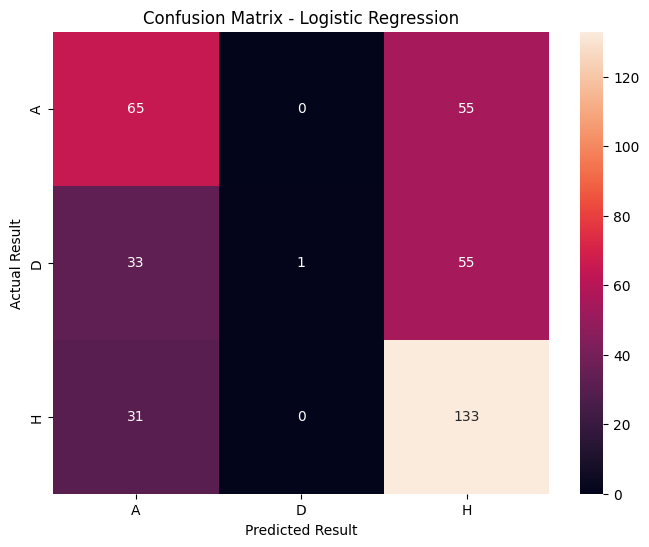

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Result")
plt.ylabel("Actual Result")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

## Model Evaluation Notes

This first model uses rolling 5-match form features to predict Premier League match outcomes.

The confusion matrix shows how often the model correctly predicts Home Wins, Draws, and Away Wins.

Draws are expected to be the hardest class to predict because they are less predictable and often depend on small match events.

In [22]:
y.value_counts(normalize=True)

target_result
H    0.438776
A    0.321160
D    0.240064
Name: proportion, dtype: float64

In [23]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [24]:
rf_predictions = rf_model.predict(X_test)

In [25]:
rf_accuracy = accuracy_score(y_test, rf_predictions)

print(
    "Random Forest Accuracy:",
    round(rf_accuracy * 100, 2),
    "%"
)

Random Forest Accuracy: 42.09 %


In [26]:
print("Logistic Regression Accuracy:", round(accuracy * 100, 2), "%")

print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 53.35 %
Random Forest Accuracy: 42.09 %


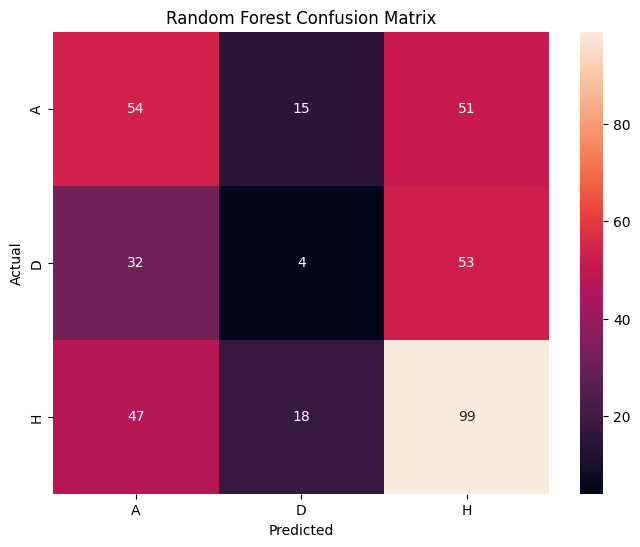

In [27]:
rf_cm = confusion_matrix(
    y_test,
    rf_predictions,
    labels=labels
)

plt.figure(figsize=(8,6))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [28]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
7,away_last_5_goal_difference,0.129996
6,home_last_5_goal_difference,0.128140
0,home_last_5_points,0.126781
5,away_last_5_avg_goals_against,0.125413
2,home_last_5_avg_goals_for,0.123771
1,away_last_5_points,0.123409
3,away_last_5_avg_goals_for,0.121866
4,home_last_5_avg_goals_against,0.120624


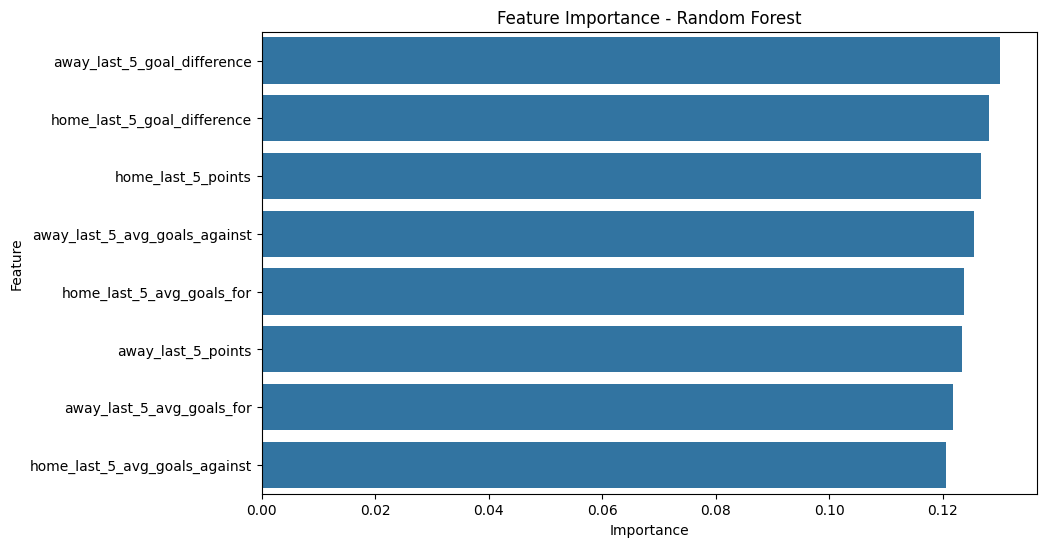

In [29]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")

plt.show()

In [30]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ]
})

model_comparison

,Model,Accuracy
0,Logistic Regression,0.533512
1,Random Forest,0.420912


In [31]:
model_comparison["Accuracy (%)"] = model_comparison["Accuracy"] * 100

model_comparison

,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.533512,53.351206
1,Random Forest,0.420912,42.091153


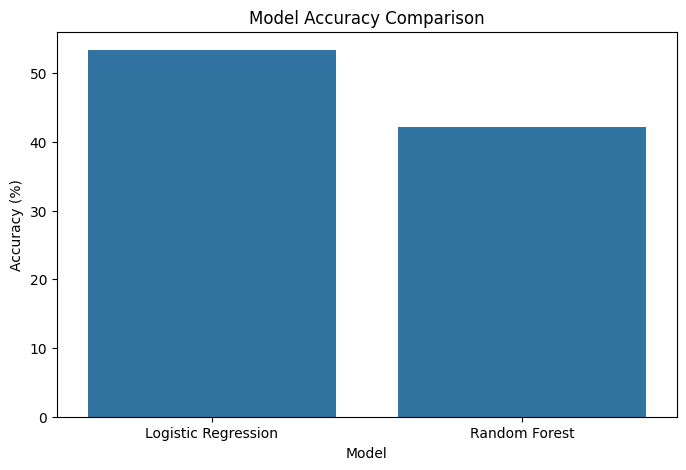

In [32]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="Accuracy (%)"
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xlabel("Model")

plt.show()

## Model Comparison Interpretation

This comparison shows how the baseline Logistic Regression model performed against a Random Forest model.

Logistic Regression is useful as a simple baseline model, while Random Forest can capture more complex relationships between recent team form, attacking strength, and defensive weakness.

The better-performing model will be used as the current candidate model for the match prediction system.

In [33]:
probabilities = model.predict_proba(X_test)

probabilities[:5]

array([[0.11113754, 0.21086489, 0.67799756],
       [0.36475621, 0.27329029, 0.3619535 ],
       [0.23873392, 0.24467598, 0.5165901 ],
       [0.14900135, 0.21500877, 0.63598988],
       [0.20475804, 0.24347964, 0.55176232]])

In [34]:
model.classes_

array(['A', 'D', 'H'], dtype=object)

In [35]:
probability_df = pd.DataFrame(
    probabilities,
    columns=model.classes_
)

probability_df.head()

,A,D,H
0,0.111138,0.210865,0.677998
1,0.364756,0.273290,0.361954
2,0.238734,0.244676,0.516590
3,0.149001,0.215009,0.635990
4,0.204758,0.243480,0.551762


In [36]:
probability_df["Actual Result"] = y_test.values

probability_df["Predicted Result"] = predictions

In [37]:
probability_df.head(10)

,A,D,H,Actual Result,Predicted Result
0,0.111138,0.210865,0.677998,A,H
1,0.364756,0.273290,0.361954,A,A
2,0.238734,0.244676,0.516590,H,H
3,0.149001,0.215009,0.635990,H,H
4,0.204758,0.243480,0.551762,H,H
5,0.420855,0.265542,0.313603,D,A
6,0.359644,0.263224,0.377131,H,H
7,0.566481,0.221849,0.211670,A,A
8,0.118536,0.198039,0.683425,D,H
9,0.292276,0.241813,0.465911,H,H


In [38]:
probability_df = probability_df.rename(columns={
    "A": "Away Win Probability",
    "D": "Draw Probability",
    "H": "Home Win Probability"
})

probability_df.head()

,Away Win Probability,Draw Probability,Home Win Probability,Actual Result,Predicted Result
0,0.111138,0.210865,0.677998,A,H
1,0.364756,0.273290,0.361954,A,A
2,0.238734,0.244676,0.516590,H,H
3,0.149001,0.215009,0.635990,H,H
4,0.204758,0.243480,0.551762,H,H


## Probability Prediction Interpretation

Instead of only predicting a single match result, the Logistic Regression model can also estimate probabilities for each possible outcome.

This provides a more realistic representation of football uncertainty and allows the system to evaluate prediction confidence levels.

In [39]:
sample_match = pd.DataFrame({
    "home_last_5_points": [12],
    "away_last_5_points": [5],

    "home_last_5_avg_goals_for": [2.1],
    "away_last_5_avg_goals_for": [1.0],

    "home_last_5_avg_goals_against": [0.8],
    "away_last_5_avg_goals_against": [1.7],

    "home_last_5_goal_difference": [1.3],
    "away_last_5_goal_difference": [-0.7]
})

sample_match

,home_last_5_points,away_last_5_points,home_last_5_avg_goals_for,away_last_5_avg_goals_for,home_last_5_avg_goals_against,away_last_5_avg_goals_against,home_last_5_goal_difference,away_last_5_goal_difference
0,12,5,2.1,1.0,0.8,1.7,1.3,-0.7


In [40]:
sample_prediction = model.predict(sample_match)

sample_prediction

array(['H'], dtype=object)

In [41]:
sample_probabilities = model.predict_proba(sample_match)

sample_probabilities

array([[0.18942497, 0.16559426, 0.64498077]])

In [42]:
prediction_df = pd.DataFrame(
    sample_probabilities,
    columns=model.classes_
)

prediction_df = prediction_df.rename(columns={
    "A": "Away Win Probability",
    "D": "Draw Probability",
    "H": "Home Win Probability"
})

prediction_df

,Away Win Probability,Draw Probability,Home Win Probability
0,0.189425,0.165594,0.644981


In [43]:
prediction_df = prediction_df * 100

prediction_df

,Away Win Probability,Draw Probability,Home Win Probability
0,18.942497,16.559426,64.498077


## Manual Match Prediction Example

This section demonstrates how the trained Logistic Regression model can generate predictions for a new hypothetical Premier League match.

By manually inputting recent team performance metrics, the system estimates outcome probabilities for:
- Home Win
- Draw
- Away Win

This forms the foundation for future deployment into an interactive Streamlit prediction application.

In [44]:
prediction_results = df.loc[X_test.index, [
    "season",
    "match_date",
    "home_team",
    "away_team",
    "target_result"
]].copy()

prediction_results["predicted_result"] = predictions

prediction_results["away_win_probability"] = probability_df["Away Win Probability"].values
prediction_results["draw_probability"] = probability_df["Draw Probability"].values
prediction_results["home_win_probability"] = probability_df["Home Win Probability"].values

prediction_results.head()

,season,match_date,home_team,away_team,target_result,predicted_result,away_win_probability,draw_probability,home_win_probability
1515,25-26,2025-08-23,Man City,Tottenham,A,H,0.111138,0.210865,0.677998
856,23-24,2023-11-11,Crystal Palace,Everton,A,A,0.364756,0.273290,0.361954
1490,24-25,2025-05-18,Leicester,Ipswich,H,H,0.238734,0.244676,0.516590
475,22-23,2022-10-22,Man City,Brighton,H,H,0.149001,0.215009,0.635990
1820,25-26,2026-04-12,Sunderland,Tottenham,H,H,0.204758,0.243480,0.551762


In [45]:
prediction_results["prediction_correct"] = (
    prediction_results["target_result"] == prediction_results["predicted_result"]
)

prediction_results.head()

,season,match_date,home_team,away_team,target_result,predicted_result,away_win_probability,draw_probability,home_win_probability,prediction_correct
1515,25-26,2025-08-23,Man City,Tottenham,A,H,0.111138,0.210865,0.677998,False
856,23-24,2023-11-11,Crystal Palace,Everton,A,A,0.364756,0.273290,0.361954,True
1490,24-25,2025-05-18,Leicester,Ipswich,H,H,0.238734,0.244676,0.516590,True
475,22-23,2022-10-22,Man City,Brighton,H,H,0.149001,0.215009,0.635990,True
1820,25-26,2026-04-12,Sunderland,Tottenham,H,H,0.204758,0.243480,0.551762,True


In [46]:
result_mapping = {
    "H": "Home Win",
    "D": "Draw",
    "A": "Away Win"
}

prediction_results["actual_result_label"] = prediction_results["target_result"].map(result_mapping)
prediction_results["predicted_result_label"] = prediction_results["predicted_result"].map(result_mapping)

prediction_results.head()

,season,match_date,home_team,away_team,target_result,predicted_result,away_win_probability,draw_probability,home_win_probability,prediction_correct,actual_result_label,predicted_result_label
1515,25-26,2025-08-23,Man City,Tottenham,A,H,0.111138,0.210865,0.677998,False,Away Win,Home Win
856,23-24,2023-11-11,Crystal Palace,Everton,A,A,0.364756,0.273290,0.361954,True,Away Win,Away Win
1490,24-25,2025-05-18,Leicester,Ipswich,H,H,0.238734,0.244676,0.516590,True,Home Win,Home Win
475,22-23,2022-10-22,Man City,Brighton,H,H,0.149001,0.215009,0.635990,True,Home Win,Home Win
1820,25-26,2026-04-12,Sunderland,Tottenham,H,H,0.204758,0.243480,0.551762,True,Home Win,Home Win


In [47]:
prediction_results.to_csv(
    "../data/processed/ml_prediction_results.csv",
    index=False
)

In [48]:
feature_importance.to_csv(
    "../data/processed/ml_feature_importance.csv",
    index=False
)

## Export All Match Predictions for Power BI

The previous prediction export only included the test set. This export uses the trained model to generate predictions for every match in the dataset so Power BI can display full seasons.

In [50]:
all_predictions = model.predict(X)

all_probabilities = model.predict_proba(X)

In [51]:
all_prediction_results = df[
    [
        "season",
        "match_date",
        "home_team",
        "away_team",
        "target_result"
    ]
].copy()

all_prediction_results["predicted_result"] = all_predictions

In [52]:
all_probability_df = pd.DataFrame(
    all_probabilities,
    columns=model.classes_
)

all_probability_df = all_probability_df.rename(columns={
    "A": "Away Win Probability",
    "D": "Draw Probability",
    "H": "Home Win Probability"
})

all_prediction_results["away_win_probability"] = all_probability_df["Away Win Probability"].values
all_prediction_results["draw_probability"] = all_probability_df["Draw Probability"].values
all_prediction_results["home_win_probability"] = all_probability_df["Home Win Probability"].values

In [53]:
all_prediction_results["prediction_correct"] = (
    all_prediction_results["target_result"] ==
    all_prediction_results["predicted_result"]
)

In [54]:
result_mapping = {
    "H": "Home Win",
    "D": "Draw",
    "A": "Away Win"
}

all_prediction_results["actual_result_label"] = all_prediction_results["target_result"].map(result_mapping)
all_prediction_results["predicted_result_label"] = all_prediction_results["predicted_result"].map(result_mapping)

In [55]:
all_prediction_results.head()

,season,match_date,home_team,away_team,target_result,predicted_result,away_win_probability,draw_probability,home_win_probability,prediction_correct,actual_result_label,predicted_result_label
0,21-22,2021-08-21,Liverpool,Burnley,H,H,0.238525,0.111759,0.649716,True,Home Win,Home Win
1,21-22,2021-08-21,Aston Villa,Newcastle,H,H,0.282812,0.172751,0.544437,True,Home Win,Home Win
2,21-22,2021-08-21,Crystal Palace,Brentford,D,D,0.412930,0.497232,0.089837,True,Draw,Draw
3,21-22,2021-08-21,Leeds,Everton,D,D,0.376432,0.521437,0.102132,True,Draw,Draw
4,21-22,2021-08-21,Man City,Norwich,H,H,0.313413,0.185428,0.501159,True,Home Win,Home Win


In [56]:
all_prediction_results.to_csv(
    "../data/processed/ml_all_match_predictions.csv",
    index=False
)

## Logistic Regression Feature Coefficients

In [58]:
logistic_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

logistic_coefficients

,Feature,Coefficient
0,home_last_5_points,-0.038080
1,away_last_5_points,-0.000890
2,home_last_5_avg_goals_for,-0.032969
3,away_last_5_avg_goals_for,0.096650
4,home_last_5_avg_goals_against,-0.088340
5,away_last_5_avg_goals_against,-0.054454
6,home_last_5_goal_difference,-0.047160
7,away_last_5_goal_difference,0.031276


In [59]:
logistic_coefficients["Absolute Coefficient"] = (
    logistic_coefficients["Coefficient"].abs()
)

logistic_coefficients

,Feature,Coefficient,Absolute Coefficient
0,home_last_5_points,-0.038080,0.038080
1,away_last_5_points,-0.000890,0.000890
2,home_last_5_avg_goals_for,-0.032969,0.032969
3,away_last_5_avg_goals_for,0.096650,0.096650
4,home_last_5_avg_goals_against,-0.088340,0.088340
5,away_last_5_avg_goals_against,-0.054454,0.054454
6,home_last_5_goal_difference,-0.047160,0.047160
7,away_last_5_goal_difference,0.031276,0.031276


In [60]:
logistic_coefficients = logistic_coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

logistic_coefficients

,Feature,Coefficient,Absolute Coefficient
3,away_last_5_avg_goals_for,0.096650,0.096650
4,home_last_5_avg_goals_against,-0.088340,0.088340
5,away_last_5_avg_goals_against,-0.054454,0.054454
6,home_last_5_goal_difference,-0.047160,0.047160
0,home_last_5_points,-0.038080,0.038080
2,home_last_5_avg_goals_for,-0.032969,0.032969
7,away_last_5_goal_difference,0.031276,0.031276
1,away_last_5_points,-0.000890,0.000890


In [61]:
logistic_coefficients.to_csv(
    "../data/processed/ml_logistic_coefficients.csv",
    index=False
)